# Changing Neutrino Parameters in Cosmology Backends

This notebook validates the neutrino interface in different cloelib cosmology backends.
Each backend is validated against their original library.

We also validate that that different backends return the same results for the same neutrino parameters like $\Omega_\nu$ and $N_{\rm eff}$.

For each of the backends, we check the following:
- $H(z)$
- $\chi(z)$
- $P^{\rm lin}(k)$
- $P^{\rm nl}(k)$

Showing the quantities and their relative percent error:  $\delta = \frac{A_{\rm cloelib} - A_{\rm original}}{A_{\rm original}} \times 100\%$

The models we will validate are:
- `mnu = 0.0`, `N_ur = 3.044`, `N_mnu = 0`
- `mnu = 0.12`, `N_ur = 2.0308`, `N_mnu = 1` (single neutrinos)
- `mnu = 0.02, 0.04, 0.06`, `N_ur = 3.044`, `N_mnu = 3` (non-degenerate neutrinos)

## Backends validated in this notebook
- cloelib[camb]
- cloelib[class] ✅
- ...

# 

<style>
details summary {
  font-size: 1.25em;    /* roughly H3 size */
  font-weight: bold;
  cursor: pointer;
}
</style>
<details>
<summary><strong>📑 Notebook Table of Contents</strong></summary>

- [Set-up](#Set-up)
  - [Fiducial Cosmology](#fiducial-cosmology)
- [CLASS Comparisson](#class-comparisson)
  - [CLASS Set-up](#class-set-up)
  - [cloelib[class] Set-up](#cloelibclass-set-up)
  - [CLASS Comparisson: Plots](#class-comparisson-plots)
    - [CLASS Comparisson: $H(z)$](#class-comparisson-hz)
    - [CLASS Comparisson: $\chi(z)$](#class-comparisson-chiz)
    - [CLASS Comparisson: $P^{lin}(k)$](#class-comparisson-plink)
    - [CLASS Comparisson: $P^{nl}(k)$](#class-comparisson-pnlk)
- [CAMB Comparisson](#camb-comparisson)
  - [CAMB Set-up](#camb-set-up)
  - [cloelib[camb] Set-up](#cloelibcamb-set-up)
  - [CAMB Comparisson: Plots](#camb-comparisson-plots)
    - [CAMB Comparisson: $H(z)$](#camb-comparisson-hz)
    - [CAMB Comparisson: $\chi(z)$](#camb-comparisson-chiz)
    - [CAMB Comparisson: $P^{lin}(k)$](#camb-comparisson-plink)
    - [CAMB Comparisson: $P^{nl}(k)$](#camb-comparisson-pnlk)
</details>

# Set-up
This section sets up the notebook, imports the necessary libraries, and defines the fiducial cosmology parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import (
    CAMBBackground,
    CAMBLinearPerturbations,
    CAMBNonLinearPerturbations
)
from cloelib.cosmology.class_cosmology import (
    CLASSBackground,
    CLASSLinearPerturbations,
    CLASSNonLinearPerturbations
)
from cloelib.auxiliary.units import SPEED_OF_LIGHT

c0 = SPEED_OF_LIGHT/1000

# Plot style
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)


## Fiducial Cosmology
- $\Lambda$ CDM
- No massive neutrinos, i.e., $\sum m_\nu = 0$, $N_{\rm eff} = 3.044$, $N_{\rm m\nu} = 0$
- Mead2020 for the non-linear power spectrum

_Same cosmology as in the `validation_ccl.ipynb` notebook._

In [2]:
cosmo_dict = {
    'H0': 67.7,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'Omega_k':0,
    'omch2': 0.25*0.677**2,
    'ombh2': 0.05*0.677**2,
    'w0': -1,
    'wa':0,
    'ns':0.95,
    'As':2e-9,
    'mnu':0.0,
    'nnu':3.044,
    'N_eff':3.044,
    'halofit_version':'mead2020'
}

# Redshift array to compute power spectra and define n(z)'s
zs = np.linspace(0.0, 3., 100) 
# fourier modes
ks = np.logspace(np.log10(1e-4), np.log10(3.0), 100)

# Class comparisson

In this section we will validate the CLASS backend for the neutrino interface in `cloelib`.

## Class Set-up

### Model 1 
`mnu = 0.0`, `N_ur = 3.044`, `N_mnu = 0`

In [3]:
from classy import Class
import classy

print('Using CLASS %s'%(classy.__version__))

# Linear power spectrum parameters for CLASS
class_fiducial_params = {
    'output': 'mPk,mTk',
    'k_per_decade_for_bao': 70,
    'k_per_decade_for_pk': 10,
    'non linear': 'none',
    'z_max_pk': np.max(zs),
    'P_k_max_1/Mpc': np.max(ks),
    # fiducial cosmology parameters
    'H0': cosmo_dict['H0'],
    'omega_cdm': cosmo_dict['omch2'],
    'omega_b': cosmo_dict['ombh2'],
    'n_s': cosmo_dict['ns'],
    'A_s': cosmo_dict['As'],
    'Omega_k': cosmo_dict['Omega_k'],
    'use_ppf': 'yes',
    'Omega_Lambda': 0.0,
    'w0_fld': cosmo_dict['w0'],
    'wa_fld': cosmo_dict['wa'],
    'N_ur': cosmo_dict['N_eff'],
    'N_ncdm': 0,  # No massive neutrinos
}

# Linear Model 1
results_class_M1 = Class()
results_class_M1.set(class_fiducial_params)
results_class_M1.compute()

# Non-linear power spectrum parameters for CLASS
class_fiducial_nonlinear_params = deepcopy(class_fiducial_params)
class_fiducial_nonlinear_params['non linear'] = 'hmcode'
class_fiducial_nonlinear_params['nonlinear_min_k_max'] = 50
class_fiducial_nonlinear_params['hmcode_tol_sigma'] = 1e-8

# Non-linear Model 1
results_class_M1_nl = Class()
results_class_M1_nl.set(class_fiducial_nonlinear_params)
results_class_M1_nl.compute()


# quantities of interest
class_M1_Hubble = np.array([results_class_M1.Hubble(z) for z in zs]) * c0  # km/s/Mpc
class_M1_chi = np.array([results_class_M1.comoving_distance(z) for z in zs])
class_M1_pk = np.array([[results_class_M1.pk(ki, zi) for ki in ks] for zi in zs])
class_M1_pk_nl = np.array([[results_class_M1_nl.pk(ki, zi) for ki in ks] for zi in zs])


Using CLASS v3.3.1


### Model 2
`mnu = 0.12`, `N_ur = 2.0308`, `N_mnu = 3` (single neutrinos)

In [4]:
class_M2_params = deepcopy(class_fiducial_params)
class_M2_params['m_ncdm'] = '0.12'
class_M2_params['N_ncdm'] = 1
class_M2_params['N_ur'] = 2.0308

# Linear Model 2
results_class_M2 = Class()
results_class_M2.set(class_M2_params)
results_class_M2.compute()

# Non-linear power spectrum parameters for CLASS M2
class_M2_nonlinear_params = deepcopy(class_M2_params)
class_M2_nonlinear_params['non linear'] = 'hmcode'
class_M2_nonlinear_params['nonlinear_min_k_max'] = 50
class_M2_nonlinear_params['hmcode_tol_sigma'] = 1e-8

# Non-linear Model 1
results_class_M2_nl = Class()
results_class_M2_nl.set(class_M2_nonlinear_params)
results_class_M2_nl.compute()


# quantities of interest
class_M2_Hubble = np.array([results_class_M2.Hubble(z) for z in zs]) * c0  # km/s/Mpc
class_M2_chi = np.array([results_class_M2.comoving_distance(z) for z in zs])
class_M2_pk = np.array([[results_class_M2.pk(ki, zi) for ki in ks] for zi in zs])
class_M2_pk_nl = np.array([[results_class_M2_nl.pk(ki, zi) for ki in ks] for zi in zs])

### Model 3
`mnu = 0.02, 0.04, 0.06`, `N_ur = 0.0044`, `N_mnu = 3` (non degenerate neutrinos)

In [5]:
class_M3_params = deepcopy(class_fiducial_params)
class_M3_params['m_ncdm'] = '0.02, 0.04, 0.06'
class_M3_params['N_ncdm'] = 3
class_M3_params['N_ur'] = 0.0044

# Linear Model 2
results_class_M3 = Class()
results_class_M3.set(class_M3_params)
results_class_M3.compute()

# Non-linear power spectrum parameters for CLASS M2
class_M3_nonlinear_params = deepcopy(class_M3_params)
class_M3_nonlinear_params['non linear'] = 'hmcode'
class_M3_nonlinear_params['nonlinear_min_k_max'] = 50
class_M3_nonlinear_params['hmcode_tol_sigma'] = 1e-8

# Non-linear Model 1
results_class_M3_nl = Class()
results_class_M3_nl.set(class_M3_nonlinear_params)
results_class_M3_nl.compute()


# quantities of interest
class_M3_Hubble = np.array([results_class_M3.Hubble(z) for z in zs]) * c0  # km/s/Mpc
class_M3_chi = np.array([results_class_M3.comoving_distance(z) for z in zs])
class_M3_pk = np.array([[results_class_M3.pk(ki, zi) for ki in ks] for zi in zs])
class_M3_pk_nl = np.array([[results_class_M3_nl.pk(ki, zi) for ki in ks] for zi in zs])

## cloelib[class] set-up

### Model 1 
`mnu = 0.0`, `N_ur = 3.044`, `N_mnu = 0`

In [6]:
cloeclass_M1 = CLASSBackground(
    H0=cosmo_dict['H0'], 
    Omega_b0=cosmo_dict['Omega_b'], 
    Omega_cdm0=cosmo_dict['Omega_c'], 
    Omega_k0=cosmo_dict['Omega_k'], 
    As=cosmo_dict['As'], 
    ns=cosmo_dict['ns'], 
    mnu=cosmo_dict['mnu'], 
    w0=cosmo_dict['w0'], 
    wa=cosmo_dict['wa'], 
    N_mnu=0,  # No massive neutrinos
    gamma_MG=0.0
)

# background quantities
cloeclass_M1_Hubble = cloeclass_M1.hubble_parameter(zs)
cloeclass_M1_chi = cloeclass_M1.comoving_distance(zs)

cloeclass_M1_linear = CLASSLinearPerturbations(background=cloeclass_M1, redshifts=zs)
cloeclass_M1_nonlinear = CLASSNonLinearPerturbations(background=cloeclass_M1, 
                                                  redshifts=zs, 
                                                  nonlinear_model='hmcode')

cloeclass_M1_pk = cloeclass_M1_linear.matter_power_spectrum(zs, ks)
cloeclass_M1_pk_nl = cloeclass_M1_nonlinear.matter_power_spectrum(zs, ks)

### Model 2
`mnu = 0.12`, `N_ur = 2.0308`, `N_mnu = 1` (single neutrinos)

In [7]:
cloeclass_M2 = CLASSBackground(
    H0=cosmo_dict['H0'], 
    Omega_b0=cosmo_dict['Omega_b'], 
    Omega_cdm0=cosmo_dict['Omega_c'], 
    Omega_k0=cosmo_dict['Omega_k'], 
    As=cosmo_dict['As'], 
    ns=cosmo_dict['ns'], 
    mnu=0.12, 
    w0=cosmo_dict['w0'], 
    wa=cosmo_dict['wa'], 
    N_mnu=1,  # single neutrinos
    gamma_MG=0.0
)

# background quantities
cloeclass_M2_Hubble = cloeclass_M2.hubble_parameter(zs)
cloeclass_M2_chi = cloeclass_M2.comoving_distance(zs)

cloeclass_M2_linear = CLASSLinearPerturbations(background=cloeclass_M2, redshifts=zs)
cloeclass_M2_nonlinear = CLASSNonLinearPerturbations(background=cloeclass_M2, 
                                                     redshifts=zs, 
                                                     nonlinear_model='hmcode')

cloeclass_M2_pk = cloeclass_M2_linear.matter_power_spectrum(zs, ks)
cloeclass_M2_pk_nl = cloeclass_M2_nonlinear.matter_power_spectrum(zs, ks)

### Model 3
`mnu = 0.02, 0.04, 0.06`, `N_ur = 0.0044`, `N_mnu = 3` (non degenerate neutrinos)

In [8]:
cloeclass_M3 = CLASSBackground(
    H0=cosmo_dict['H0'], 
    Omega_b0=cosmo_dict['Omega_b'], 
    Omega_cdm0=cosmo_dict['Omega_c'], 
    Omega_k0=cosmo_dict['Omega_k'], 
    As=cosmo_dict['As'], 
    ns=cosmo_dict['ns'], 
    mnu=[0.02,0.04,0.06], 
    w0=cosmo_dict['w0'], 
    wa=cosmo_dict['wa'], 
    N_mnu=3, 
    gamma_MG=0.0
)

# background quantities
cloeclass_M3_Hubble = cloeclass_M3.hubble_parameter(zs)
cloeclass_M3_chi = cloeclass_M3.comoving_distance(zs)

cloeclass_M3_linear = CLASSLinearPerturbations(background=cloeclass_M3, redshifts=zs)
cloeclass_M3_nonlinear = CLASSNonLinearPerturbations(background=cloeclass_M3, 
                                                     redshifts=zs, 
                                                     nonlinear_model='hmcode')

cloeclass_M3_pk = cloeclass_M3_linear.matter_power_spectrum(zs, ks)
cloeclass_M3_pk_nl = cloeclass_M3_nonlinear.matter_power_spectrum(zs, ks)

## CLASS Comparisson: Plots

This section plots the results of the CLASS validation for the neutrino interface in `cloelib[class]`.


### CLASS Comparisson: $H(z)$

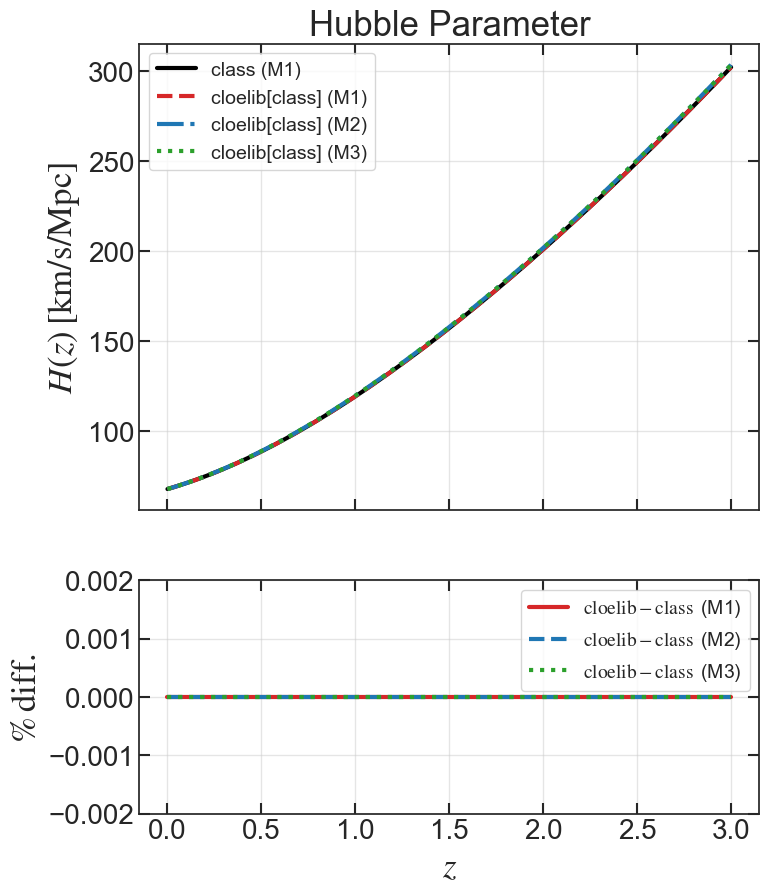

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

# not showing the class M2 and M3 results here for clarity
axs[0].set_title(r'Hubble Parameter', fontsize=25)
axs[0].set_ylabel(r'$H_{\rm}(z)\: [\rm{km/s/Mpc}]$', fontsize=25)
axs[0].plot(zs,  class_M1_Hubble, color='black',  label=r'class (M1)')
axs[0].plot(zs,  cloeclass_M1_Hubble, color='tab:red', ls='--', label=r'cloelib[class] (M1)')
axs[0].plot(zs,  cloeclass_M2_Hubble, color='tab:blue', ls='-.', label=r'cloelib[class] (M2)')
axs[0].plot(zs,  cloeclass_M3_Hubble, color='tab:green', ls=':', label=r'cloelib[class] (M3)')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$z$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(zs, (cloeclass_M1_Hubble - class_M1_Hubble)/class_M1_Hubble*100, color='tab:red', ls='-', label=r'$\rm{cloelib-class}\,$ (M1)')
axs[1].plot(zs, (cloeclass_M2_Hubble - class_M2_Hubble)/class_M2_Hubble*100, color='tab:blue', ls='--', label=r'$\rm{cloelib-class}\,$ (M2)')
axs[1].plot(zs, (cloeclass_M3_Hubble - class_M3_Hubble)/class_M3_Hubble*100, color='tab:green', ls=':', label=r'$\rm{cloelib-class}\,$ (M3)')

axs[1].legend()
# axs[1].set_xscale('log')
axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


### CLASS Comparisson: $\chi(z)$

/var/folders/zj/nw2dp_t501j_g9h3tl6kybwh0000gn/T/ipykernel_82938/1252483055.py:16: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(zs, (cloeclass_M1_chi - class_M1_chi)/class_M1_chi*100, color='tab:red', ls='-', label=r'$\rm{cloelib-class}\,$ (M1)')
/var/folders/zj/nw2dp_t501j_g9h3tl6kybwh0000gn/T/ipykernel_82938/1252483055.py:17: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(zs, (cloeclass_M2_chi - class_M2_chi)/class_M2_chi*100, color='tab:blue', ls='--', label=r'$\rm{cloelib-class}\,$ (M2)')
/var/folders/zj/nw2dp_t501j_g9h3tl6kybwh0000gn/T/ipykernel_82938/1252483055.py:18: RuntimeWarning: invalid value encountered in divide
  axs[1].plot(zs, (cloeclass_M3_chi - class_M3_chi)/class_M3_chi*100, color='tab:green', ls=':', label=r'$\rm{cloelib-class}\,$ (M3)')


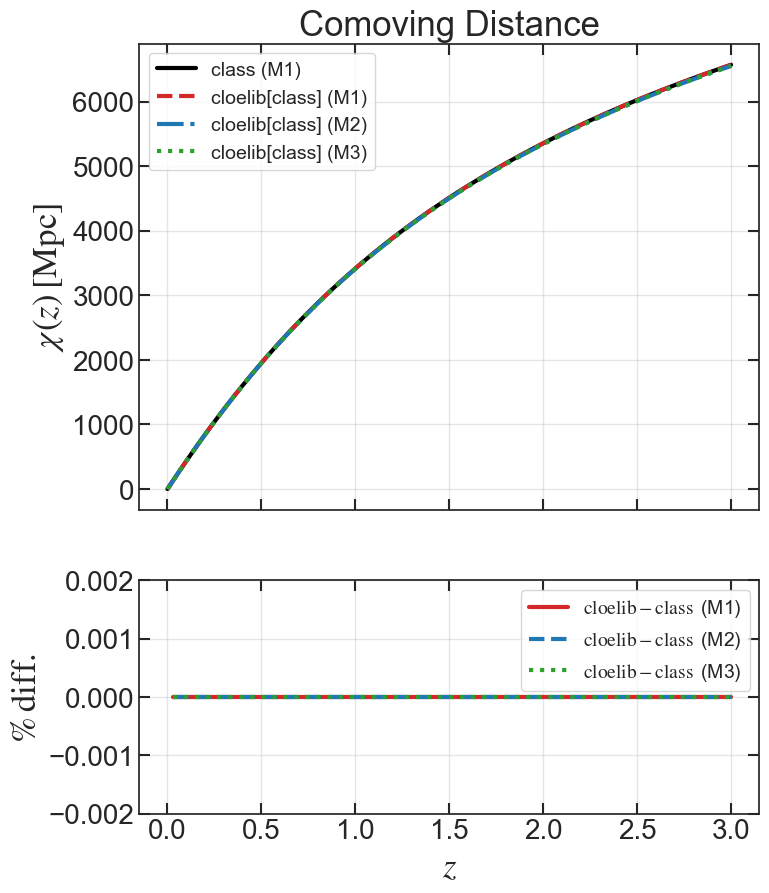

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

# not showing the class M2 and M3 results here for clarity
axs[0].set_title(r'Comoving Distance', fontsize=25)
axs[0].set_ylabel(r'$\chi_{\rm}(z)\: [\rm{Mpc}]$', fontsize=25)
axs[0].plot(zs,  class_M1_chi, color='black',  label=r'class (M1)')
axs[0].plot(zs,  cloeclass_M1_chi, color='tab:red', ls='--', label=r'cloelib[class] (M1)')
axs[0].plot(zs,  cloeclass_M2_chi, color='tab:blue', ls='-.', label=r'cloelib[class] (M2)')
axs[0].plot(zs,  cloeclass_M3_chi, color='tab:green', ls=':', label=r'cloelib[class] (M3)')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$z$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(zs, (cloeclass_M1_chi - class_M1_chi)/class_M1_chi*100, color='tab:red', ls='-', label=r'$\rm{cloelib-class}\,$ (M1)')
axs[1].plot(zs, (cloeclass_M2_chi - class_M2_chi)/class_M2_chi*100, color='tab:blue', ls='--', label=r'$\rm{cloelib-class}\,$ (M2)')
axs[1].plot(zs, (cloeclass_M3_chi - class_M3_chi)/class_M3_chi*100, color='tab:green', ls=':', label=r'$\rm{cloelib-class}\,$ (M3)')

axs[1].legend()
# axs[1].set_xscale('log')
axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)

### CLASS Comparisson: $P^{lin}(k)$

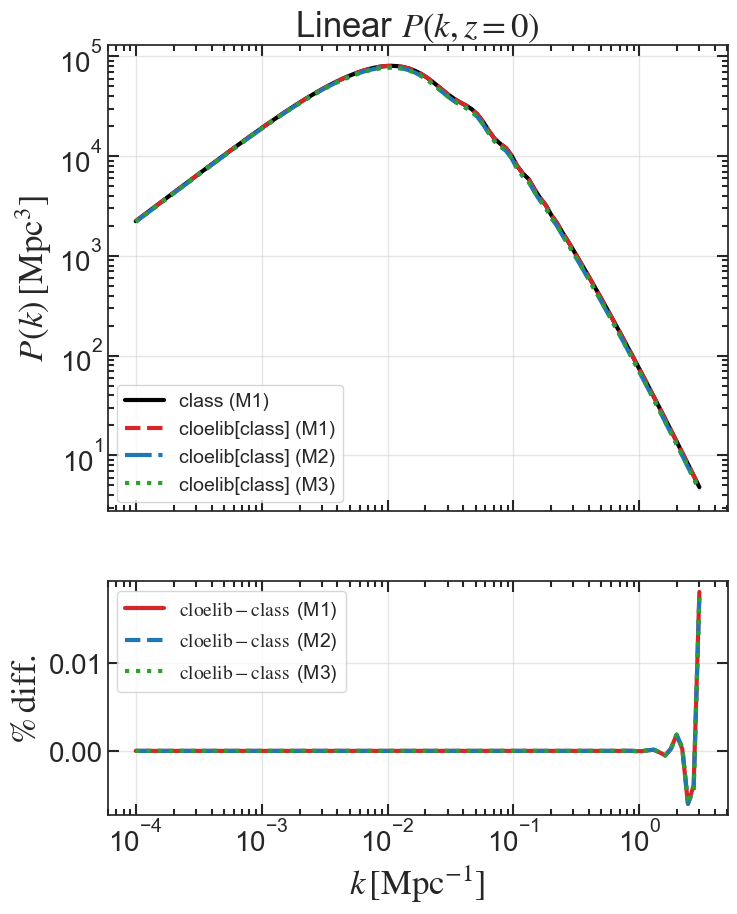

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'Linear $P(k, z=0)$', fontsize=25)
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$', fontsize=25)
axs[0].loglog(ks,  class_M1_pk[0,:], color='black',  label=r'class (M1)')
axs[0].loglog(ks,  cloeclass_M1_pk[0,:], color='tab:red', ls='--', label=r'cloelib[class] (M1)')
axs[0].loglog(ks,  cloeclass_M2_pk[0,:], color='tab:blue', ls='-.', label=r'cloelib[class] (M2)')
axs[0].loglog(ks,  cloeclass_M3_pk[0,:], color='tab:green', ls=':', label=r'cloelib[class] (M3)')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\,[\rm{Mpc}^{-1}]$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(ks, (cloeclass_M1_pk[0,:] - class_M1_pk[0,:])/class_M1_pk[0,:]*100, color='tab:red', ls='-', label=r'$\rm{cloelib-class}\,$ (M1)')
axs[1].plot(ks, (cloeclass_M2_pk[0,:] - class_M2_pk[0,:])/class_M2_pk[0,:]*100, color='tab:blue', ls='--', label=r'$\rm{cloelib-class}\,$ (M2)')
axs[1].plot(ks, (cloeclass_M3_pk[0,:] - class_M3_pk[0,:])/class_M3_pk[0,:]*100, color='tab:green', ls=':', label=r'$\rm{cloelib-class}\,$ (M3)')

axs[1].legend()
axs[1].set_xscale('log')
#axs[1].set_ylim([-0.002, 0.002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)

### CLASS Comparisson: $P^{nl}(k)$

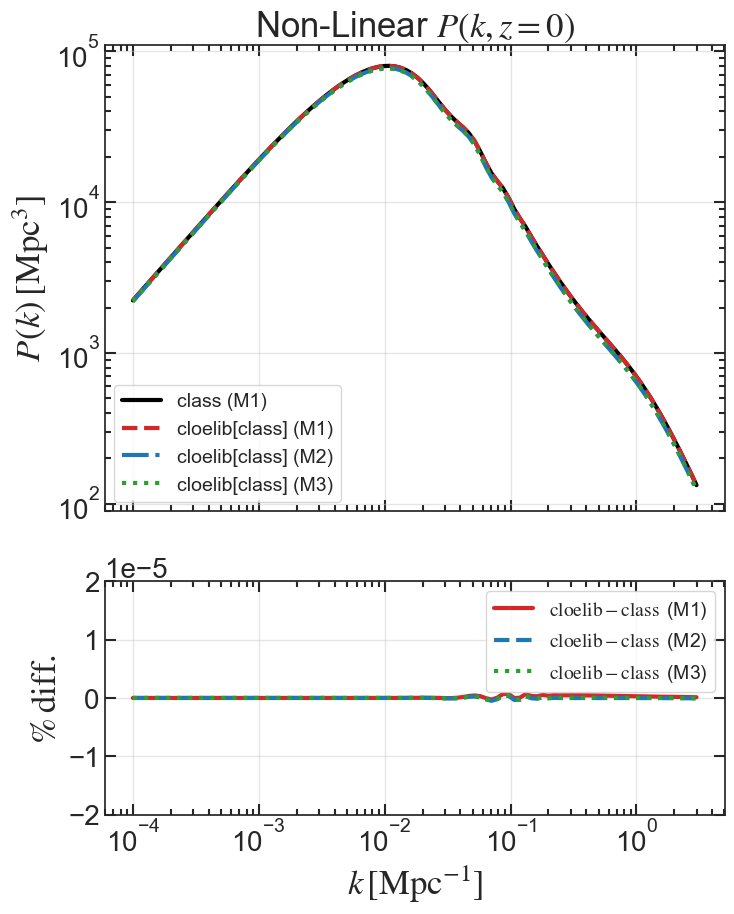

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'Non-Linear $P(k, z=0)$', fontsize=25)
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$', fontsize=25)
axs[0].loglog(ks,  class_M1_pk_nl[0,:], color='black',  label=r'class (M1)')
axs[0].loglog(ks,  cloeclass_M1_pk_nl[0,:], color='tab:red', ls='--', label=r'cloelib[class] (M1)')
axs[0].loglog(ks,  cloeclass_M2_pk_nl[0,:], color='tab:blue', ls='-.', label=r'cloelib[class] (M2)')
axs[0].loglog(ks,  cloeclass_M3_pk_nl[0,:], color='tab:green', ls=':', label=r'cloelib[class] (M3)')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\,[\rm{Mpc}^{-1}]$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(ks, (cloeclass_M1_pk_nl[0,:] - class_M1_pk_nl[0,:])/class_M1_pk_nl[0,:]*100, color='tab:red', ls='-', label=r'$\rm{cloelib-class}\,$ (M1)')
axs[1].plot(ks, (cloeclass_M2_pk_nl[0,:] - class_M2_pk_nl[0,:])/class_M2_pk_nl[0,:]*100, color='tab:blue', ls='--', label=r'$\rm{cloelib-class}\,$ (M2)')
axs[1].plot(ks, (cloeclass_M3_pk_nl[0,:] - class_M3_pk_nl[0,:])/class_M3_pk_nl[0,:]*100, color='tab:green', ls=':', label=r'$\rm{cloelib-class}\,$ (M3)')


axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-0.00002, 0.00002])
# axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)

# CAMB Comparisson

In this section we will validate the CAMB backend for the neutrino interface in `cloelib`.

In [13]:
import camb
print('Using CAMB %s'%(camb.__version__))

# Give cosmology dictionary to CAMB
camb_fiducial_params = camb.set_params(
    H0=cosmo_dict['H0'], 
    ombh2=cosmo_dict['ombh2'],
    omch2=cosmo_dict['omch2'], 
    mnu=cosmo_dict['mnu'],
    omk=cosmo_dict['Omega_k'],  
    As=cosmo_dict['As'],
    ns=cosmo_dict['ns'], 
    halofit_version=cosmo_dict['halofit_version']
)

camb_fiducial_params.set_matter_power(redshifts=zs, kmax=300) 

# Compute linear P(k)
results = camb.get_results(camb_fiducial_params)
ks = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False,)[0]
pk_lin_camb = results.get_matter_power_interpolator(nonlinear=False, hubble_units=False, k_hunit=False, extrap_kmax=300).P(0,ks)

# Compute non-linear P(k) with Mead2020 halofit version
pk_nonlin_camb = results.get_matter_power_interpolator(nonlinear=True, hubble_units=False, k_hunit=False).P(0,ks)

Using CAMB 1.6.1
Note: redshifts have been re-sorted (earliest first)
